# Notebooks and Version Control

This notebook has been committed to git with its outputs saved. Try the following:

1. Open this file in Jupyter.
2. Run the cells (Cell → Run All).
3. Save the notebook.
4. In a terminal, run `git diff noisy_diffs.ipynb`.

**None of the code has changed**, but the diff will be huge. Read on for why.

In [5]:
import datetime
print("Run at:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Run at: 2026-05-12 22:36:06


In [6]:
for i in range(1, 6):
    print(f"{i} squared is {i * i}")

1 squared is 1
2 squared is 4
3 squared is 9
4 squared is 16
5 squared is 25


In [7]:
[i * i for i in range(10)]

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

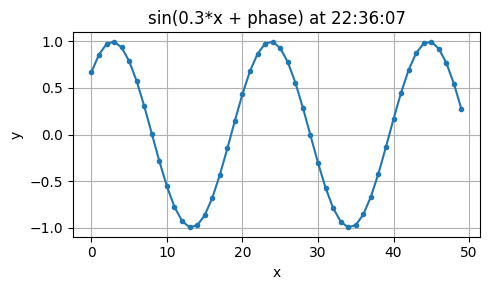

In [8]:
import datetime
import math
import matplotlib.pyplot as plt

now = datetime.datetime.now()
secs = now.hour * 3600 + now.minute * 60 + now.second
phase = (secs % 60) / 60.0 * 2 * math.pi

xs = list(range(50))
ys = [math.sin(0.3 * x + phase) for x in xs]

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(xs, ys, marker="o", markersize=3)
ax.set_title(f"sin(0.3*x + phase) at {now.strftime('%H:%M:%S')}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
fig.tight_layout()
plt.show()

## Why is the diff so noisy?

Jupyter notebooks are JSON files that store *both* the code and its outputs. Every cell carries an `execution_count` and an `outputs` array. Even if you change nothing about the code:

- The `execution_count` of every re-run cell changes.
- Any output that depends on time, randomness, or external state (e.g., the timestamp cell and the plot above) is rewritten with new content.
- Cell IDs, metadata, and trailing whitespace inside JSON strings may also shift.

## What about images?

The plot above is a worst case. The `phase` of the sine wave depends on the current time, so the plot will look *slightly* different each time the cell is re-run — but the underlying PNG is embedded in the notebook as a base64 string thousands of characters long, and *every byte* of that string changes. Git sees two enormous, unreadable blobs and reports a massive diff for what is, visually, almost the same image.

## Merge conflicts

Now imagine two collaborators both edit this notebook on different branches and try to merge. Git tries to reconcile the JSON line by line, which mangles the structure. Resolving the conflict by hand means hand-editing JSON — including matching braces, commas, and base64 strings — without breaking the notebook format.